# Sentiment Analysis
- Focus: sentiment distribution, emotion distribution, sentiment vs rating, sentiment by city/location type, strongest positive/negative destinations.
- Input: `Processed_Reviews.csv` unless `INPUT_FILE` env var is set.
- Outputs: sentiment/ratings crosstabs, sentiment by grouping CSVs, plots for quick inspection.

In [1]:
# Imports and display options
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

INPUT_FILE = os.getenv("INPUT_FILE", "Processed_Reviews.csv")
MIN_REVIEWS_GROUP = 20

In [2]:
# Load final dataset
df = pd.read_csv(INPUT_FILE)
print(f"Loaded: {INPUT_FILE}")
print("Shape:", df.shape)

Loaded: Processed_Reviews.csv
Shape: (16156, 41)


In [3]:
# Validate required columns
required_cols = ["Combined_Sentiment", "Sentiment_Score", "Emotion", "Rating"]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

In [4]:
# Overall sentiment and emotion distribution
print("\n=== Combined Sentiment Distribution ===")
print(df["Combined_Sentiment"].value_counts())

print("\n=== Combined Sentiment Percentage ===")
print((df["Combined_Sentiment"].value_counts(normalize=True) * 100).round(2))

print("\n=== Emotion Distribution ===")
print(df["Emotion"].value_counts())

print("\n=== Average Sentiment Score by Sentiment Class ===")
print(df.groupby("Combined_Sentiment")["Sentiment_Score"].mean())


=== Combined Sentiment Distribution ===
Combined_Sentiment
POSITIVE    12764
NEUTRAL      1818
NEGATIVE     1574
Name: count, dtype: int64

=== Combined Sentiment Percentage ===
Combined_Sentiment
POSITIVE    79.00
NEUTRAL     11.25
NEGATIVE     9.74
Name: proportion, dtype: float64

=== Emotion Distribution ===
Emotion
joy         8431
neutral     3552
surprise    1643
fear         967
sadness      836
disgust      578
anger        149
Name: count, dtype: int64

=== Average Sentiment Score by Sentiment Class ===
Combined_Sentiment
NEGATIVE    0.731542
NEUTRAL     0.583907
POSITIVE    0.892536
Name: Sentiment_Score, dtype: float64


In [5]:
# Sentiment vs rating
print("\n=== Sentiment vs Rating Crosstab ===")
sentiment_rating_table = pd.crosstab(df["Rating"], df["Combined_Sentiment"])
print(sentiment_rating_table)

print("\n=== Row-wise Percentage: Sentiment within each Rating ===")
sentiment_rating_pct = pd.crosstab(
    df["Rating"], df["Combined_Sentiment"], normalize="index"
).round(3) * 100
print(sentiment_rating_pct)


=== Sentiment vs Rating Crosstab ===
Combined_Sentiment  NEGATIVE  NEUTRAL  POSITIVE
Rating                                         
1                        407       48        32
2                        425      125       108
3                        496      519      1151
4                        157      570      4469
5                         89      556      7004

=== Row-wise Percentage: Sentiment within each Rating ===
Combined_Sentiment  NEGATIVE  NEUTRAL  POSITIVE
Rating                                         
1                       83.6      9.9       6.6
2                       64.6     19.0      16.4
3                       22.9     24.0      53.1
4                        3.0     11.0      86.0
5                        1.2      7.3      91.6


In [6]:
# Average sentiment score by rating
print("\n=== Average Sentiment Score by Rating ===")
avg_sentiment_score_by_rating = df.groupby("Rating")["Sentiment_Score"].mean()
print(avg_sentiment_score_by_rating)


=== Average Sentiment Score by Rating ===
Rating
1    0.796642
2    0.707380
3    0.708604
4    0.844494
5    0.892807
Name: Sentiment_Score, dtype: float64


In [7]:
# Sentiment by location type
if "Location_Type" in df.columns:
    sentiment_by_type = (
        df.groupby("Location_Type")
          .agg(
              Review_Count=("Combined_Sentiment", "count"),
              Avg_Sentiment_Score=("Sentiment_Score", "mean")
          )
          .reset_index()
    )

    sentiment_by_type = sentiment_by_type[
        sentiment_by_type["Review_Count"] >= MIN_REVIEWS_GROUP
    ].sort_values(by="Avg_Sentiment_Score", ascending=False)

    print(f"\n=== Sentiment by Location Type (min {MIN_REVIEWS_GROUP} reviews) ===")
    print(sentiment_by_type)
else:
    sentiment_by_type = None
    print("\nLocation_Type not found.")


=== Sentiment by Location Type (min 20 reviews) ===
              Location_Type  Review_Count  Avg_Sentiment_Score
3                   Gardens          1354             0.871021
2                     Farms          1884             0.870847
0                   Beaches          2110             0.846788
6            National Parks          1205             0.846289
1           Bodies of Water           839             0.837683
7   Nature & Wildlife Areas          1557             0.837260
9                Waterfalls           933             0.836826
10       Zoological Gardens           213             0.835633
4            Historic Sites          1519             0.833969
8           Religious Sites          3017             0.829383
5                   Museums          1525             0.816105


In [8]:
# Sentiment by city
if "Located_City" in df.columns:
    sentiment_by_city = (
        df.groupby("Located_City")
          .agg(
              Review_Count=("Combined_Sentiment", "count"),
              Avg_Sentiment_Score=("Sentiment_Score", "mean")
          )
          .reset_index()
    )

    sentiment_by_city = sentiment_by_city[
        sentiment_by_city["Review_Count"] >= MIN_REVIEWS_GROUP
    ].sort_values(by="Avg_Sentiment_Score", ascending=False)

    top_sentiment_cities = sentiment_by_city.head(15)
    bottom_sentiment_cities = sentiment_by_city.tail(15)

    print(f"\n=== Top Cities by Sentiment Score (min {MIN_REVIEWS_GROUP} reviews) ===")
    print(top_sentiment_cities)

    print(f"\n=== Bottom Cities by Sentiment Score (min {MIN_REVIEWS_GROUP} reviews) ===")
    print(bottom_sentiment_cities)
else:
    sentiment_by_city = None
    top_sentiment_cities = None
    bottom_sentiment_cities = None
    print("\nLocated_City not found.")


=== Top Cities by Sentiment Score (min 20 reviews) ===
     Located_City  Review_Count  Avg_Sentiment_Score
16     Kalametiya           132             0.960677
26     Peradeniya           337             0.927741
0        Ahangama           304             0.919183
5         Bentota           233             0.905083
10   Embilipitiya           149             0.901769
35      Weligatta           189             0.892426
22        Mirissa           217             0.892024
32  Tissamaharama            91             0.887513
11          Galle           511             0.879879
17       Kalkudah           160             0.872014
4      Arugam Bay           187             0.870988
6        Beruwala           292             0.867275
2          Ampara            35             0.862826
20     Katukitula           302             0.859429
29     Pussellawa           223             0.858159

=== Bottom Cities by Sentiment Score (min 20 reviews) ===
    Located_City  Review_Count  Avg_S

In [9]:
# Sentiment by destination
if "Location_Name" in df.columns:
    sentiment_by_destination = (
        df.groupby("Location_Name")
          .agg(
              Review_Count=("Combined_Sentiment", "count"),
              Avg_Sentiment_Score=("Sentiment_Score", "mean")
          )
          .reset_index()
    )

    sentiment_by_destination = sentiment_by_destination[
        sentiment_by_destination["Review_Count"] >= MIN_REVIEWS_GROUP
    ].sort_values(by="Avg_Sentiment_Score", ascending=False)

    top_sentiment_destinations = sentiment_by_destination.head(15)
    bottom_sentiment_destinations = sentiment_by_destination.tail(15)

    print(f"\n=== Top Destinations by Sentiment Score (min {MIN_REVIEWS_GROUP} reviews) ===")
    print(top_sentiment_destinations)

    print(f"\n=== Bottom Destinations by Sentiment Score (min {MIN_REVIEWS_GROUP} reviews) ===")
    print(bottom_sentiment_destinations)
else:
    sentiment_by_destination = None
    top_sentiment_destinations = None
    bottom_sentiment_destinations = None
    print("\nLocation_Name not found.")


=== Top Destinations by Sentiment Score (min 20 reviews) ===
                                Location_Name  Review_Count  \
31               Kalametiya Eco Bird Watching           132   
60                    Royal Botanical Gardens           337   
23                     Handunugoda Tea Estate           304   
5                               Bentota Beach           233   
71                    Udawalawe National Park           149   
17                                 Galle Fort           283   
8                       Bundala National Park           189   
22                Halpewatte Tea Factory Tour           264   
45                              Mirissa Beach           217   
69                                 Tissa Wewa            91   
41  Martin Wickramasinghe Folk Museum Complex            86   
6                       Bluefield Tea Gardens           314   
1                              Ambewela Farms           136   
46                        Mount Lavinia Beach           

In [10]:
# Emotion by rating
print("\n=== Emotion Distribution by Rating ===")
emotion_rating_table = pd.crosstab(df["Rating"], df["Emotion"])
print(emotion_rating_table)


=== Emotion Distribution by Rating ===
Emotion  anger  disgust  fear   joy  neutral  sadness  surprise
Rating                                                         
1           39      147    67    16       68      107        43
2           21      129    63    69      135      149        92
3           41      140   163   628      699      228       267
4           25       90   264  2884     1300      158       475
5           23       72   410  4834     1350      194       766


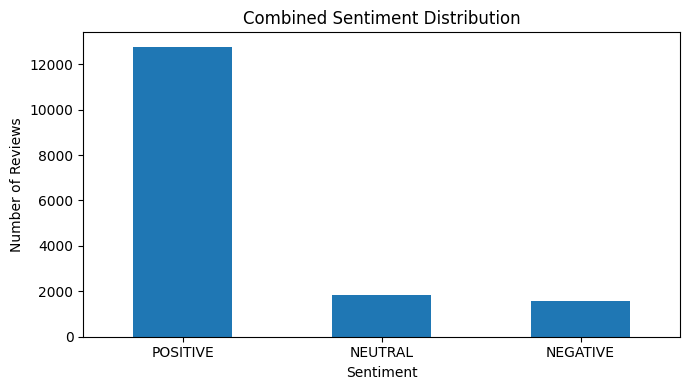

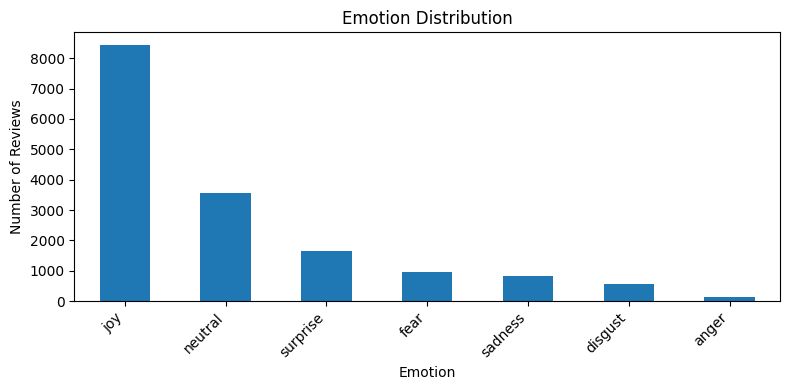

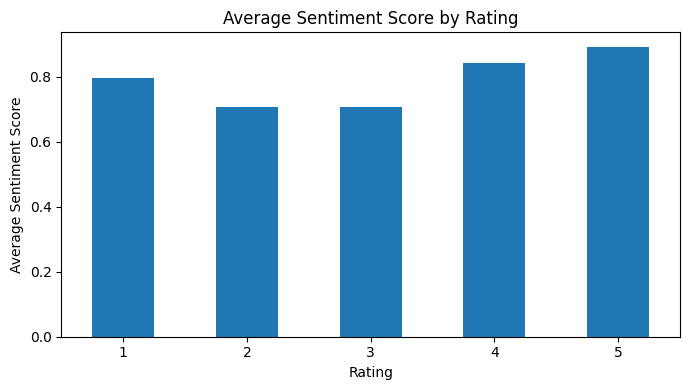

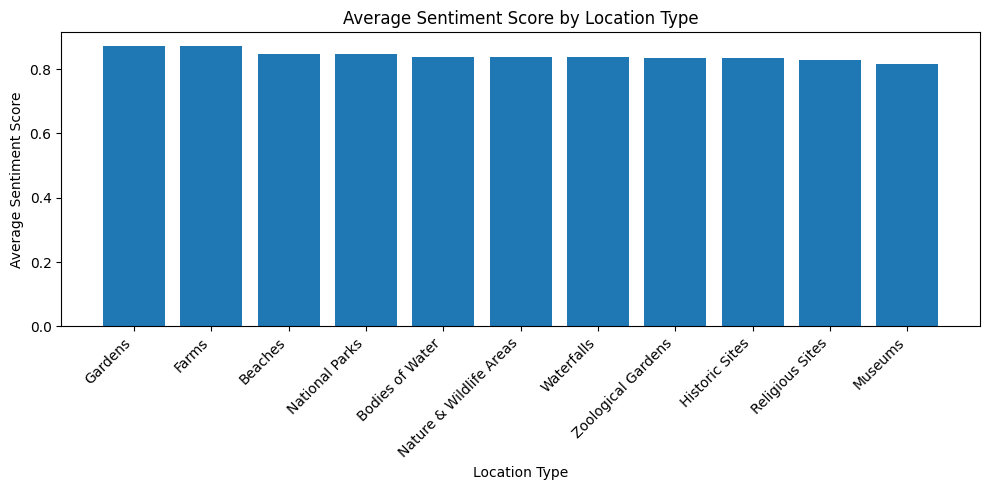

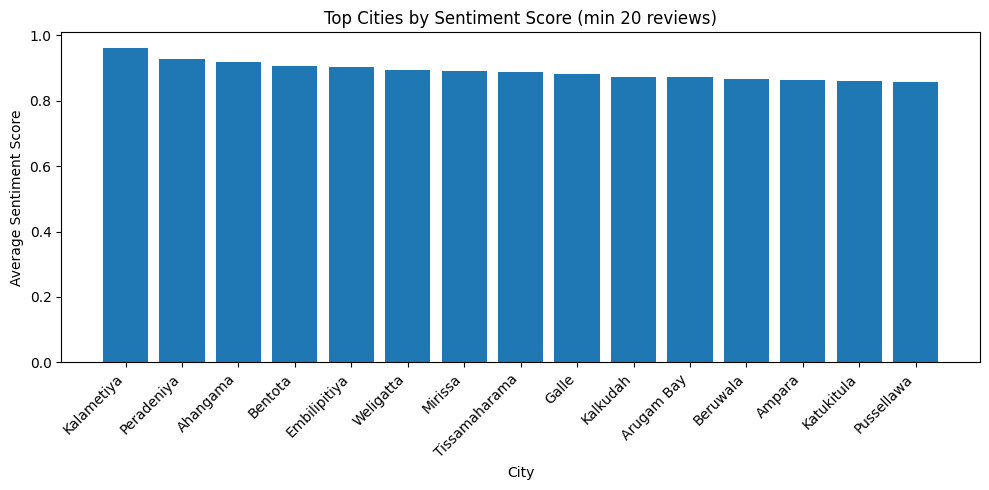

In [11]:
# Plots
plt.figure(figsize=(7, 4))
df["Combined_Sentiment"].value_counts().plot(kind="bar")
plt.title("Combined Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
df["Emotion"].value_counts().plot(kind="bar")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
avg_sentiment_score_by_rating.plot(kind="bar")
plt.title("Average Sentiment Score by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

if sentiment_by_type is not None and not sentiment_by_type.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(sentiment_by_type["Location_Type"], sentiment_by_type["Avg_Sentiment_Score"])
    plt.title("Average Sentiment Score by Location Type")
    plt.xlabel("Location Type")
    plt.ylabel("Average Sentiment Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if top_sentiment_cities is not None and not top_sentiment_cities.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(top_sentiment_cities["Located_City"], top_sentiment_cities["Avg_Sentiment_Score"])
    plt.title(f"Top Cities by Sentiment Score (min {MIN_REVIEWS_GROUP} reviews)")
    plt.xlabel("City")
    plt.ylabel("Average Sentiment Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [12]:
# Save outputs
sentiment_rating_table.to_csv("sentiment_rating_crosstab.csv")
sentiment_rating_pct.to_csv("sentiment_rating_percentage.csv")
avg_sentiment_score_by_rating.to_csv("avg_sentiment_score_by_rating.csv")

if sentiment_by_type is not None:
    sentiment_by_type.to_csv("sentiment_by_location_type.csv", index=False)

if sentiment_by_city is not None:
    sentiment_by_city.to_csv("sentiment_by_city.csv", index=False)

if sentiment_by_destination is not None:
    sentiment_by_destination.to_csv("sentiment_by_destination.csv", index=False)

emotion_rating_table.to_csv("emotion_by_rating.csv")

print("\n✅ Sentiment analysis complete.")
print("Saved files:")
print("- sentiment_rating_crosstab.csv")
print("- sentiment_rating_percentage.csv")
print("- avg_sentiment_score_by_rating.csv")
print("- emotion_by_rating.csv")
if sentiment_by_type is not None:
    print("- sentiment_by_location_type.csv")
if sentiment_by_city is not None:
    print("- sentiment_by_city.csv")
if sentiment_by_destination is not None:
    print("- sentiment_by_destination.csv")


✅ Sentiment analysis complete.
Saved files:
- sentiment_rating_crosstab.csv
- sentiment_rating_percentage.csv
- avg_sentiment_score_by_rating.csv
- emotion_by_rating.csv
- sentiment_by_location_type.csv
- sentiment_by_city.csv
- sentiment_by_destination.csv
